# IMPORT LIBRARIES

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    Activation
)

from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# GENERATE SYNTHETIC TEXTURE DATASET

In [ ]:
import numpy as np

# Parameters
NUM_SAMPLES = 10000
IMG_HEIGHT = 30
IMG_WIDTH = 60
NUM_CLASSES = 10

# Create empty arrays
X = np.zeros((NUM_SAMPLES, IMG_HEIGHT, IMG_WIDTH), dtype=np.float32)
y_integer_labels = np.zeros(NUM_SAMPLES, dtype=np.int32) # Stores integer labels

# Generate synthetic texture patterns

In [ ]:
for i in range(NUM_SAMPLES):

    label = np.random.randint(0, NUM_CLASSES)
    y_integer_labels[i] = label # Store integer label

    img = np.zeros((IMG_HEIGHT, IMG_WIDTH))

    # Different texture patterns for each class
    if label == 0:
        img = np.random.rand(IMG_HEIGHT, IMG_WIDTH)

    elif label == 1:
        for r in range(IMG_HEIGHT):
            img[r, :] = r / IMG_HEIGHT

    elif label == 2:
        for c in range(IMG_WIDTH):
            img[:, c] = c / IMG_WIDTH

    elif label == 3:
        img[::2, :] = 1

    elif label == 4:
        img[:, ::2] = 1

    elif label == 5:
        img[::4, :] = 1
        img[:, ::4] = 1

    elif label == 6:
        img = np.eye(IMG_HEIGHT, IMG_WIDTH)

    elif label == 7:
        img = np.fliplr(np.eye(IMG_HEIGHT, IMG_WIDTH))

    elif label == 8:
        img = np.sin(np.linspace(0, 10, IMG_WIDTH))
        img = np.tile(img, (IMG_HEIGHT, 1))

    elif label == 9:
        img = np.random.normal(0.5, 0.2, (IMG_HEIGHT, IMG_WIDTH))

    # Add small noise
    noise = np.random.normal(0, 0.05, (IMG_HEIGHT, IMG_WIDTH))
    img = img + noise

    # Normalize between 0 and 1
    img = np.clip(img, 0, 1)

    X[i] = img

# VISUALIZE DATASET

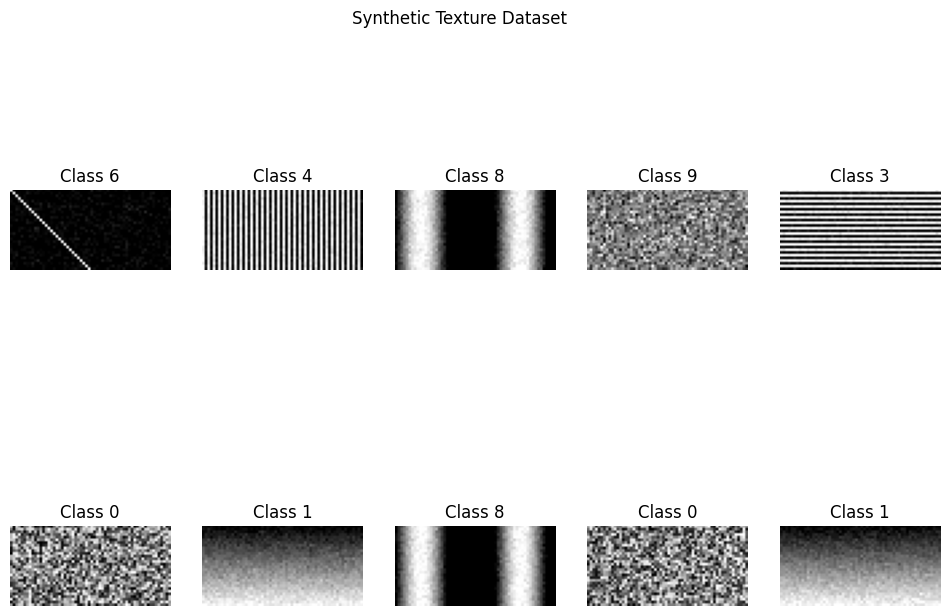

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Class {int(y_integer_labels[i])}") # Use y_integer_labels for title
    plt.axis("off")

plt.suptitle("Synthetic Texture Dataset")
plt.show()

# PREPROCESSING

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Reshape for CNN
X = X.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

# One-hot encoding using the integer labels
y_one_hot = to_categorical(y_integer_labels, NUM_CLASSES)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_one_hot, # Use the one-hot encoded labels
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (8000, 30, 60, 1)
Testing Shape : (2000, 30, 60, 1)


# BUILD CNN MODEL

In [ ]:
def build_cnn(
    activation_function='relu',
    num_conv_layers=2,
    filters=32,
    filter_size=(3,3),
    learning_rate=0.001
):

    model = Sequential()

    # --------------------------------------------------------
    # Convolution Layer 1
    # --------------------------------------------------------
    model.add(
        Conv2D(
            filters=filters,
            kernel_size=filter_size,
            padding='same',
            input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)
        )
    )

    model.add(Activation(activation_function))

    # --------------------------------------------------------
    # Max Pooling Layer
    # --------------------------------------------------------
    model.add(MaxPooling2D(pool_size=(2,2)))

    # --------------------------------------------------------
    # Additional Convolution Layers
    # --------------------------------------------------------
    for i in range(num_conv_layers - 1):

        model.add(
            Conv2D(
                filters=filters * 2,
                kernel_size=filter_size,
                padding='same'
            )
        )

        model.add(Activation(activation_function))

        model.add(MaxPooling2D(pool_size=(2,2)))

    # --------------------------------------------------------
    # Fully Connected Layer
    # --------------------------------------------------------
    model.add(Flatten())

    model.add(Dense(128))
    model.add(Activation(activation_function))

    model.add(Dropout(0.3))

    # --------------------------------------------------------
    # Softmax Output Layer
    # --------------------------------------------------------
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    optimizer = Adam(learning_rate=learning_rate)

    # --------------------------------------------------------
    # Compile Model
    # --------------------------------------------------------
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# CREATE MODEL

In [ ]:
model = build_cnn(
    activation_function='relu',
    num_conv_layers=2,
    filters=32,
    filter_size=(3,3),
    learning_rate=0.001
)

# Display model architecture
model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 60, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 30, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 15, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 15, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6720)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       860,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 880,394 (3.36 MB)

 Trainable params: 880,394 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

# TRAIN MODEL

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - accuracy: 0.9353 - loss: 0.2196 - val_accuracy: 1.0000 - val_loss: 6.7454e-04
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 5.0495e-04
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 218ms/step - accuracy: 1.0000 - loss: 7.6582e-04 - val_accuracy: 1.0000 - val_loss: 4.5307e-05
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - accuracy: 1.0000 - loss: 3.7924e-04 - val_accuracy: 1.0000 - val_loss: 2.3933e-05
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 206ms/step - accuracy: 0.9903 - loss: 0.0318 - val_accuracy: 1.0000 - val_loss: 2.1159e-04
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 191ms/step - accuracy: 1.0000 - loss: 6.6776e-04 - val_accuracy: 1.0000 - val_loss: 3.2055e-05
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 233ms/step - accuracy: 1.0000 - loss: 3.8370e-04 - val_accuracy: 1.0000 - val_loss: 1.2051e-05
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━

# EVALUATE MODEL

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 1.0000 - loss: 1.0841e-06

Test Loss     : 1.0840632285180618e-06
Test Accuracy : 1.0


# PLOT TRAINING CURVES

Training Loss vs Epochs

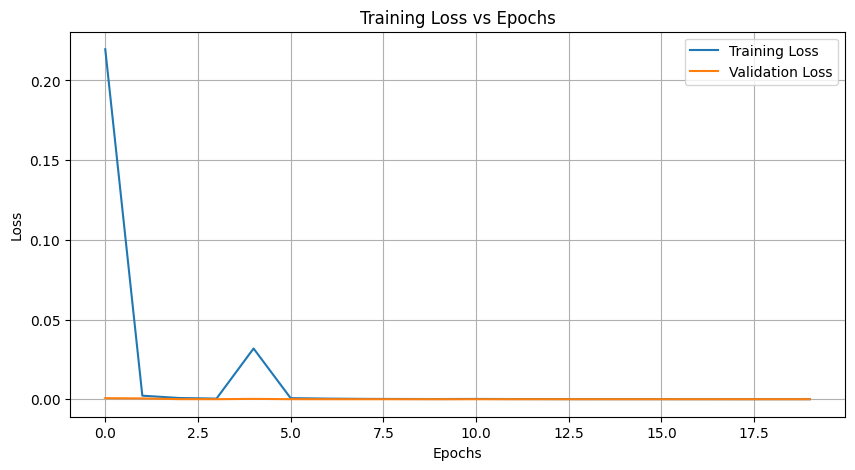

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)

plt.show()

Validation Accuracy vs Epochs

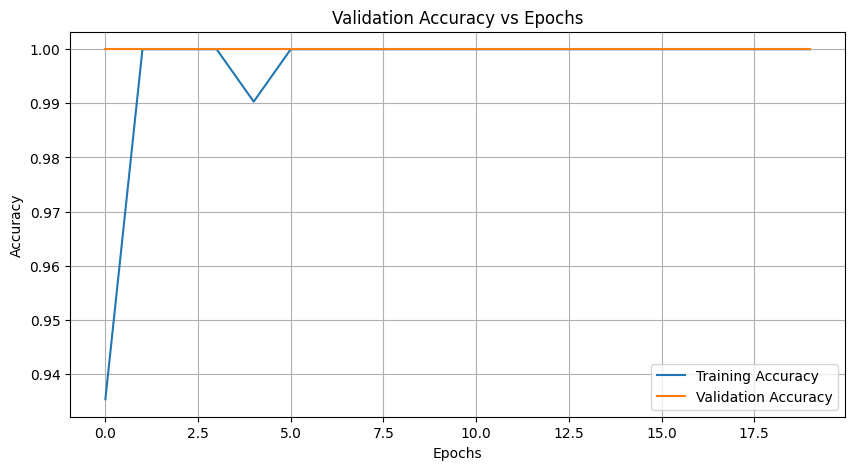

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epochs")
plt.legend()
plt.grid(True)

plt.show()

# EXPERIMENT WITH DIFFERENT ACTIVATION FUNCTIONS

In [ ]:
activation_functions = ['relu', 'sigmoid', 'tanh']

results = {}

for activation in activation_functions:

    print("\n========================================")
    print("Activation Function:", activation)
    print("========================================")

    model = build_cnn(
        activation_function=activation,
        num_conv_layers=2,
        filters=32,
        filter_size=(3,3),
        learning_rate=0.001
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=64,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results[activation] = accuracy

    print("Test Accuracy:", accuracy)


Activation Function: relu
Test Accuracy: 1.0

Activation Function: sigmoid
Test Accuracy: 0.9240000247955322

Activation Function: tanh
Test Accuracy: 1.0


DISPLAY RESULTS

In [ ]:
print("\nActivation Function Comparison")

for activation, accuracy in results.items():
    print(f"{activation} --> Accuracy = {accuracy:.4f}")


Activation Function Comparison
relu --> Accuracy = 1.0000
sigmoid --> Accuracy = 0.9240
tanh --> Accuracy = 1.0000


# DIFFERENT CNN CONFIGURATIONS

In [ ]:
configurations = [
    (1, 16, (3,3)),
    (2, 32, (3,3)),
    (3, 64, (5,5))
]

config_results = []

for conv_layers, filters, filter_size in configurations:

    print("\n===================================")
    print("Conv Layers :", conv_layers)
    print("Filters     :", filters)
    print("Filter Size :", filter_size)
    print("===================================")

    model = build_cnn(
        activation_function='relu',
        num_conv_layers=conv_layers,
        filters=filters,
        filter_size=filter_size,
        learning_rate=0.001
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=64,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    config_results.append(
        [conv_layers, filters, filter_size, accuracy]
    )


Conv Layers : 1
Filters     : 16
Filter Size : (3, 3)

Conv Layers : 2
Filters     : 32
Filter Size : (3, 3)

Conv Layers : 3
Filters     : 64
Filter Size : (5, 5)


# PRINT CONFIGURATION RESULTS

In [ ]:
print("\nCNN Configuration Results")

for result in config_results:
    print(
        f"Conv Layers={result[0]}, "
        f"Filters={result[1]}, "
        f"Filter Size={result[2]}, "
        f"Accuracy={result[3]:.4f}"
    )


CNN Configuration Results
Conv Layers=1, Filters=16, Filter Size=(3, 3), Accuracy=1.0000
Conv Layers=2, Filters=32, Filter Size=(3, 3), Accuracy=1.0000
Conv Layers=3, Filters=64, Filter Size=(5, 5), Accuracy=1.0000


# LEARNING RATE EXPERIMENT


Training with Learning Rate = 0.001

Training with Learning Rate = 0.01

Training with Learning Rate = 0.05

Training with Learning Rate = 0.1

Training with Learning Rate = 0.5


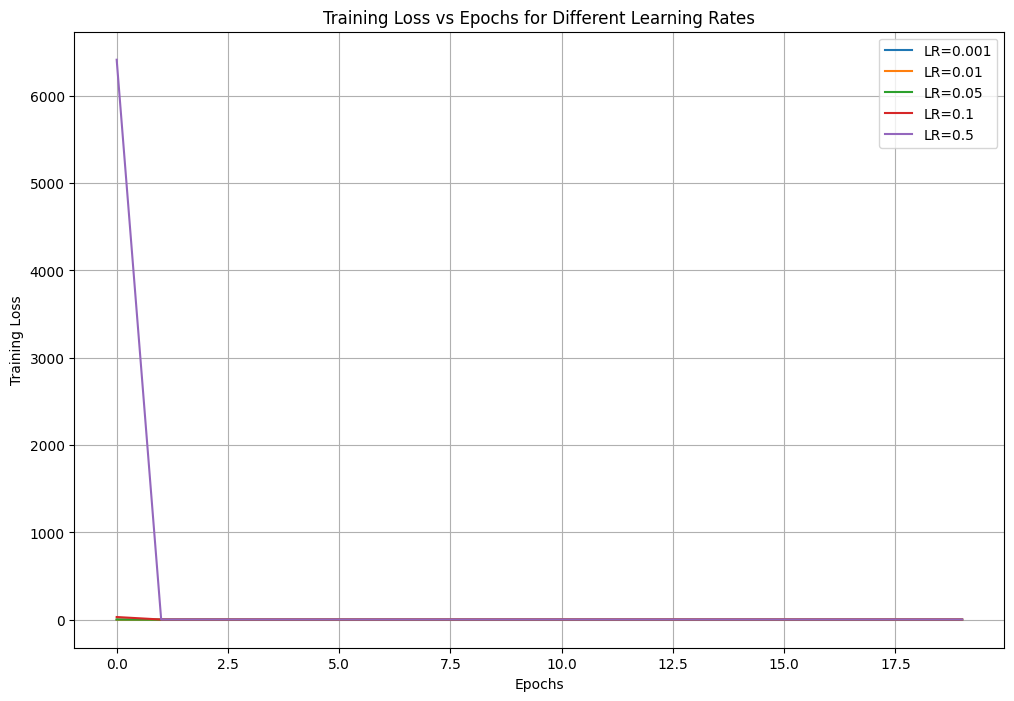

In [ ]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]

plt.figure(figsize=(12,8))

for lr in learning_rates:

    print("\nTraining with Learning Rate =", lr)

    model = build_cnn(
        activation_function='relu',
        num_conv_layers=2,
        filters=32,
        filter_size=(3,3),
        learning_rate=lr
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=64,
        verbose=0
    )

    plt.plot(
        history.history['loss'],
        label=f"LR={lr}"
    )

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.show()

# EPOCH EXPERIMENT

In [33]:
epoch_values = [50, 100, 200, 500]

for ep in epoch_values:

    print("\n================================")
    print("Training with Epochs =", ep)
    print("================================")

    model = build_cnn(
        activation_function='relu',
        num_conv_layers=2,
        filters=32,
        filter_size=(3,3),
        learning_rate=0.001
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=64,
        verbose=0
    )


Training with Epochs = 50

Training with Epochs = 100


KeyboardInterrupt: 

# Plot Accuracy

In [ ]:
    plt.figure(figsize=(10,5))

    plt.plot(
        history.history['val_accuracy'],
        label=f"Epoch={ep}"
    )

    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy")
    plt.title(f"Validation Accuracy for {ep} Epochs")
    plt.legend()
    plt.grid(True)

    plt.show()